
Interactive review of Gemini OCR bounding box results

In [1]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import Image as IPImage, display, HTML
import os


In [2]:
# Setup project paths
script_dir = Path(__file__).parent if '__file__' in dir() else Path.cwd()
project_root = script_dir if (script_dir / "data").exists() else script_dir.parent

ocr_output_file = project_root / "data" / "02_raw_batch" / "ocr_output.jsonl"
preprocessed_dir = project_root / "data" / "01_preprocessed"
preprocessed_meta_csv = preprocessed_dir / "all_metadata.csv"

print(f"Project Root: {project_root}")
print(f"OCR Output File: {ocr_output_file}")
print(f"Preprocessed Data Dir: {preprocessed_dir}")
print(f"\nFile exists: {ocr_output_file.exists()}")

Project Root: d:\Google Drive (smith318)\newspaper_ocr\newspaper_utilities
OCR Output File: d:\Google Drive (smith318)\newspaper_ocr\newspaper_utilities\data\02_raw_batch\ocr_output.jsonl
Preprocessed Data Dir: d:\Google Drive (smith318)\newspaper_ocr\newspaper_utilities\data\01_preprocessed

File exists: True


In [3]:
meta_df = pd.read_csv(preprocessed_meta_csv)
print(f"Total metadata records loaded: {len(meta_df)}")
# meta_df['x_offset'] = pd.to_numeric(meta_df['x_offset'], errors='coerce')
# meta_df['y_offset'] = pd.to_numeric(meta_df['y_offset'], errors='coerce')
# print(type(meta_df['x_offset'][0]))
print(meta_df.head())

Total metadata records loaded: 3789
    pub_id        date  page_num  column  \
0  Alabama  0000-00-00         1       0   
1  Alabama  0000-00-00         1       1   
2  Alabama  0000-00-00         1       2   
3  Alabama  0000-00-00         2       0   
4  Alabama  0000-00-00         2       1   

                                                path  x_offset  y_offset  
0  data/01_preprocessed/Alabama/Alabama_p01_r00_c...         0      1533  
1  data/01_preprocessed/Alabama/Alabama_p01_r00_c...       867      1533  
2  data/01_preprocessed/Alabama/Alabama_p01_r00_c...      1547      1533  
3  data/01_preprocessed/Alabama/Alabama_p02_r00_c...         0       221  
4  data/01_preprocessed/Alabama/Alabama_p02_r00_c...       812       221  


In [5]:
# Load OCR output from JSONL
ocr_data = []
with open(ocr_output_file, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            ocr_data.append(json.loads(line))

df_ocr = pd.DataFrame(ocr_data)

print(f"Total OCR records loaded: {len(df_ocr)}")
print(f"\nDataframe shape: {df_ocr.shape}")
print(f"\nColumn names: {df_ocr.columns.tolist()}")
print(f"\nFirst few rows:")
print(df_ocr.head())

Total OCR records loaded: 2753

Dataframe shape: (2753, 9)

Column names: ['pub', 'page', 'col', 'text', 'conf', 'x', 'y', 'width', 'height']

First few rows:
       pub  page  col                                text  conf      x  \
0  Alabama     1    0                             ALABAMA  0.95  556.0   
1  Alabama     1    0               ABANDA, 125, CHAMBERS  0.95  297.0   
2  Alabama     1    0    CLARK, JAMES THOMAS (b'76)--Ala.  0.95  297.0   
3  Alabama     1    0                       4,'11; (l'11)  0.95  335.0   
4  Alabama     1    0  Turk, Wm. Pellham-Ga.5,'92; (l'01)  0.95  296.0   

        y  width  height  
0  1554.0  166.0    21.0  
1  1601.0  434.0    21.0  
2  1622.0  686.0    21.0  
3  1642.0  168.0    21.0  
4  1662.0  548.0    21.0  


In [6]:
# Helper function to find original image file
def find_original_image(state, page_num, col_idx):
    """
    Reconstruct the original image path from preprocessed directory.
    Images are stored as: data/01_preprocessed/{state}/{state}_p{page}_r00_c{col}.jpg
    """
    
    # Construct expected filename pattern
    img_path = preprocessed_dir / state /  f"{state}_p{page_num:02d}_r00_c{col_idx:03d}.jpg"
    if img_path.exists():
        return img_path
    
    return None

# Test the function
test_result = find_original_image(df_ocr.iloc[0]['pub'] if len(df_ocr) > 0 else 'Texas', 1, 0)
print(f"Test image search result: {test_result}")
print(f"Test path exists: {test_result.exists() if test_result else False}")

Test image search result: d:\Google Drive (smith318)\newspaper_ocr\newspaper_utilities\data\01_preprocessed\Alabama\Alabama_p01_r00_c000.jpg
Test path exists: True



Item 6 of 2753
Publication: Alabama, Page: 1, Column: 0
OCR Text: ABBEVILLE, 1,141, HENRY
Bounding Box: x=297.0, y=1684.0, w=444.0, h=21.0
Bounding Box: x=297.0, y=1684.0, w=444.0, h=21.0

📷 Original Image: "D:/Google Drive (smith318)/newspaper_ocr/newspaper_utilities/data/01_preprocessed/Alabama/Alabama_p01.jpg"


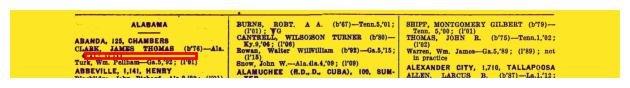

In [27]:
def display_review_item(index):
    """Display a single low-confidence item with image and text fields for correction"""
    if index >= len(df_ocr):
        print("✓ All items reviewed!")
        return
    
    row = df_ocr.iloc[index]
    orig_index = df_ocr.index[index]
    
    # Find original image
    img_path = "D:/Google Drive (smith318)/newspaper_ocr/newspaper_utilities/data/01_preprocessed/Alabama/Alabama_p01.jpg"#find_original_image(row['pub'], row['page'], row['col'])
    
    print(f"\n{'='*80}")
    print(f"Item {index + 1} of {len(df_ocr)}")
    print(f"{'='*80}")
    print(f"Publication: {row['pub']}, Page: {row['page']}, Column: {row['col']}")
    # print(f"Original Index: {orig_index}")
    print(f"OCR Text: {row['text']}")
       
    # print(f"\nContext:")
    # print(df_ocr.loc[orig_index - 3: orig_index + 4])
    # Display bounding box info
    print(f"Bounding Box: x={row['x']}, y={row['y']}, w={row['width']}, h={row['height']}")
    meta_row = meta_df.loc[
        (meta_df["pub_id"] == row['pub']) & 
        (meta_df["page_num"] == row['page']) & 
        (meta_df["column"] == row['col'])
    ][["x_offset", "y_offset"]]
    # row['x'] -= meta_row['x_offset'].iloc[0]
    # row['y'] -= meta_row['y_offset'].iloc[0]
    

    print(f"Bounding Box: x={row['x']}, y={row['y']}, w={row['width']}, h={row['height']}")
    
    # Display image if found
    if img_path:
        print(f'\n📷 Original Image: "{img_path}"')
        img = Image.open(img_path)
        # plt.figure(figsize=(10, 12))
        fig, ax = plt.subplots()
        ax.imshow(img)
        plt.axis('off')
        rect = plt.Rectangle(
            (row['x'], row['y']),
            row['width'],
            row['height'],
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )

        ax.add_patch(rect)
        #ax.set_title(f"Original Column Image - {row['pub']} p{row['page']} c{row['col']}")
        ax.set_ylim(row['y'] + 100, row['y'] - row["height"] - 150)
        plt.tight_layout()
        plt.show()
    else:
        print(f"⚠️  Original image not found at expected location")
 

# Display first low-confidence item
display_review_item(5)

In [13]:
# functions for interactions
def update_display(change=None):
    """Update display when item index changes"""
    idx = current_idx.value
    row = df_ocr.iloc[idx]
    
    context_display.value = f"""
    <b>Context:</b><br>
    {df_ocr.loc[df_ocr.index[idx] - 4: df_ocr.index[idx] - 1].to_html()}
    <b>{df_ocr.loc[[df_ocr.index[idx]]].to_html()}</b>
    {df_ocr.loc[df_ocr.index[idx] + 1: df_ocr.index[idx] + 4].to_html()}
    """
    
    # Display image
    img_path = find_original_image(row['pub'], row['page'], row['col'])
    if img_path:
        with open(img_path, "rb") as file:
            image_bytes = file.read()
        image_widget.value = image_bytes
 
def on_next(b):
    idx = current_idx.value
    if idx < len(df_ocr) - 1:
        current_idx.value = idx + 1

def on_previous(b):
    if current_idx.value > 0:
        current_idx.value = current_idx.value - 1

In [14]:

# Create review state tracking dictionary
review_state = {
    'current_index': 0,
}

# Create interactive review interface
current_idx = widgets.IntSlider(value=0, min=0, max=len(df_ocr)-1, step=1, description='Item:', width='500px')
context_display = widgets.HTML(value='')
row = df_ocr.iloc[0]
img_path = find_original_image(row['pub'], row['page'], row['col'])
if img_path:
    with open(img_path, "rb") as file:
        image_bytes = file.read()
    image_widget = widgets.Image(
        value=image_bytes,
        format='jpg',
        # width=300,
        # height=900,
        # layout=widgets.Layout(object_fit='scale-down') # Optional styling
    )

current_idx.observe(update_display, names='value')

# Buttons for navigation
btn_next = widgets.Button(description='Skip', button_style='info')
btn_previous = widgets.Button(description='Previous', button_style='warning')

btn_next.on_click(on_next)
btn_previous.on_click(on_previous)
buttons_box = widgets.HBox([btn_previous, btn_next])

# Display the interface
update_display()
display(widgets.HBox([buttons_box, image_widget, context_display]))